# Proyecto: Serpientes y Escaleras como Cadena de Markov
## Objetivo B: Cálculo del Vector Estacionario $\pi$

Dado que nuestra Cadena de Markov de 50 estados es finita, irreducible y aperiódica, la teoría nos garantiza que existe un único vector de distribución estacionaria $\pi$. Este vector satisface la ecuación $\pi P = \pi$ y $\sum \pi_i = 1$.

En este cuaderno, calcularemos $\pi$ de tres maneras distintas y compararemos su convergencia.

### Criterios de Término y Justificación
1. **Método i) Exacto (Sistema Lineal):** No requiere criterio de término iterativo, ya que resuelve directamente el sistema de ecuaciones usando álgebra lineal.
2. **Método ii) Multiplicación Matriz-Vector (Iterativo):** * *Criterio de término:* Norma L2 de la diferencia entre iteraciones $||\pi_{k+1} - \pi_k||_2 < 10^{-6}$.
   * *Justificación:* Al multiplicar sucesivamente el vector por la matriz $P$, el vector converge asintóticamente al estado estacionario. Cuando el cambio entre un paso y el siguiente es microscópico (menor a nuestra tolerancia de $10^{-6}$), asumimos que el sistema ha alcanzado el equilibrio.
3. **Método iii) Random Walk (Simulación):**
   * *Criterio de término:* Un número fijo de pasos suficientemente grande, en este caso $N = 100,000$.
   * *Justificación:* Según la Ley de los Grandes Números, la frecuencia relativa de visitas a un estado en una caminata aleatoria converge a su probabilidad estacionaria real cuando $N \rightarrow \infty$. Elegimos 100,000 pasos porque ofrece un buen balance entre precisión estocástica y tiempo de cómputo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..'))

from src.board import Board
from src.markov import build_transition_matrix
from src.solvers import solve_exact, solve_iterative, solve_random_walk

# Instanciamos el modelo
board = Board("../config/board_config.yaml")
P = build_transition_matrix(board)

# 1. Método Exacto
pi_exact = solve_exact(P)

# 2. Método Iterativo
pi_iter, history_iter = solve_iterative(P, tol=1e-6)

# 3. Simulación Random Walk
pi_rw, history_rw = solve_random_walk(P, num_steps=100000)

print(f"Iteraciones necesarias para converger (Iterativo): {len(history_iter)}")
print(f"Pasos realizados en el Random Walk: 100,000")

Iteraciones necesarias para converger (Iterativo): 52
Pasos realizados en el Random Walk: 100,000


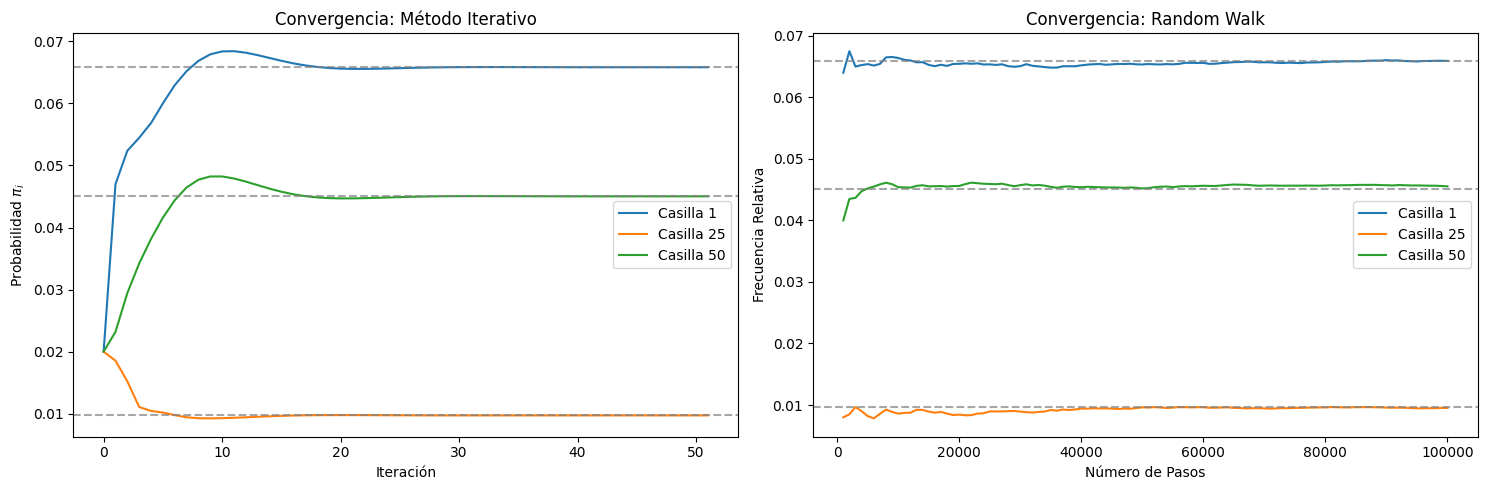

In [2]:
# Seleccionamos tres casillas representativas para observar su convergencia
casillas_idx = [0, 24, 49] # Casilla 1, Casilla 25 y Casilla 50
nombres = ['Casilla 1', 'Casilla 25', 'Casilla 50']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica 1: Convergencia del Método Iterativo
history_iter_np = np.array(history_iter)
for idx, nombre in zip(casillas_idx, nombres):
    axes[0].plot(history_iter_np[:, idx], label=nombre)
    # Línea punteada con el valor exacto teórico
    axes[0].axhline(y=pi_exact[idx], color='gray', linestyle='--', alpha=0.7)

axes[0].set_title('Convergencia: Método Iterativo')
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('Probabilidad $\pi_i$')
axes[0].legend()

# Gráfica 2: Convergencia del Random Walk
history_rw_np = np.array(history_rw)
pasos = np.arange(1000, 100000 + 1, 1000)
for idx, nombre in zip(casillas_idx, nombres):
    axes[1].plot(pasos, history_rw_np[:, idx], label=nombre)
    axes[1].axhline(y=pi_exact[idx], color='gray', linestyle='--', alpha=0.7)

axes[1].set_title('Convergencia: Random Walk')
axes[1].set_xlabel('Número de Pasos')
axes[1].set_ylabel('Frecuencia Relativa')
axes[1].legend()

plt.tight_layout()
plt.show()

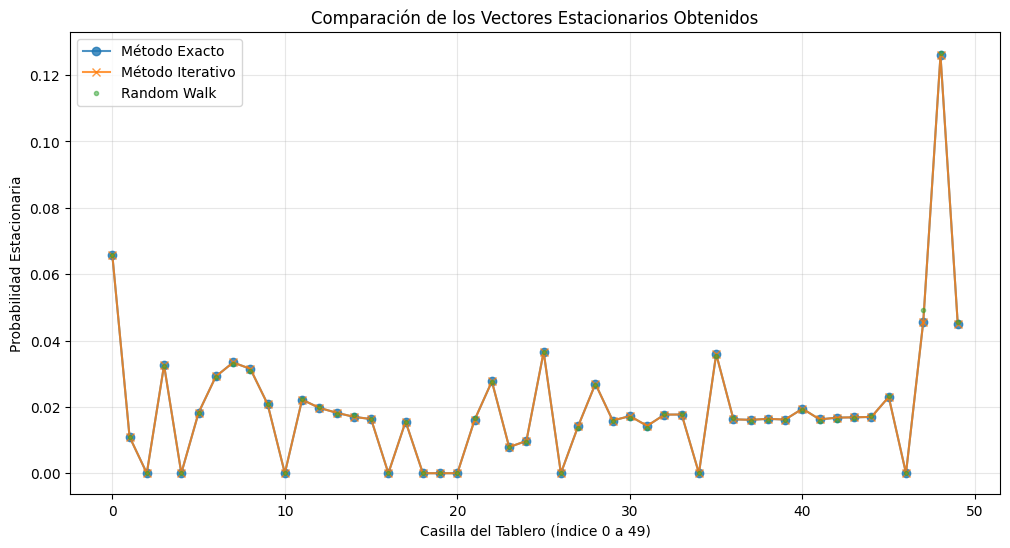

In [3]:
plt.figure(figsize=(12, 6))

# Graficamos los tres vectores resultantes
plt.plot(pi_exact, label='Método Exacto', marker='o', alpha=0.8)
plt.plot(pi_iter, label='Método Iterativo', marker='x', alpha=0.8)
plt.plot(pi_rw, label='Random Walk', marker='.', alpha=0.5, linestyle='none')

plt.title('Comparación de los Vectores Estacionarios Obtenidos')
plt.xlabel('Casilla del Tablero (Índice 0 a 49)')
plt.ylabel('Probabilidad Estacionaria')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Observaciones del Vector Estacionario $\pi$

Al analizar la convergencia de los métodos y la forma final del vector estacionario, podemos formular las siguientes dos observaciones clave:

**1. Naturaleza de la Convergencia (Determinista vs. Estocástica):**
El **Método Iterativo (Multiplicación Matriz-Vector)** exhibe una convergencia rápida y determinista. La oscilación inicial (donde la probabilidad "pasa de largo" el valor teórico y luego retrocede para estabilizarse cerca de la iteración 20) es un fenómeno característico del método de las potencias (*Power Iteration*), dictado por los valores propios complejos o negativos de la matriz de transición. Por otro lado, el **Random Walk** es inherentemente ruidoso. Aunque se aproxima al valor teórico a los 20,000 pasos, las fluctuaciones tardan mucho más en mitigarse (estabilizándose pasados los 80,000 pasos). Esto ilustra matemáticamente el Teorema del Límite Central, donde el error de la simulación Monte Carlo decae a una tasa lenta de $O(1/\sqrt{N})$.

**2. Topología del Tablero y Distribución de Probabilidad:**
El vector $\pi$ final no es uniforme, lo que demuestra cómo las reglas alteran el flujo del juego. 
* **Estados Inalcanzables al Final del Turno:** Las casillas con probabilidad $\pi_i = 0$ (como la 10 o la 20) corresponden a los inicios de escaleras o cabezas de serpiente. Es imposible terminar un turno en ellas debido a la regla del salto inmediato.
* **Cuellos de Botella (Acumulación):** Se observan picos extremos de probabilidad al final del tablero (casillas 48, 49 y 50). Esto se debe a la **regla de llegada exacta** y el "rebote", que actúa como un embudo donde los jugadores se atascan intentando sacar el número perfecto. 
* **El Ciclo Principal:** El pico inusualmente alto en la casilla 1 (índice 0) es la consecuencia directa de la regla de encadenamiento ($50 \rightarrow 1$). Toda la masa de probabilidad que finalmente logra salir del embudo del final del tablero es inyectada de golpe en la primera casilla.